In [7]:
# ============================================================
# STEP 0: Install / Import Required Libraries
# ============================================================
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:

train_dir = '/content/drive/MyDrive/AIML/Data/FruitinAmazon/train'
test_dir  = '/content/drive/MyDrive/AIML/Data/FruitinAmazon/test'


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# TASK 1: Data Understanding and Visualization

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


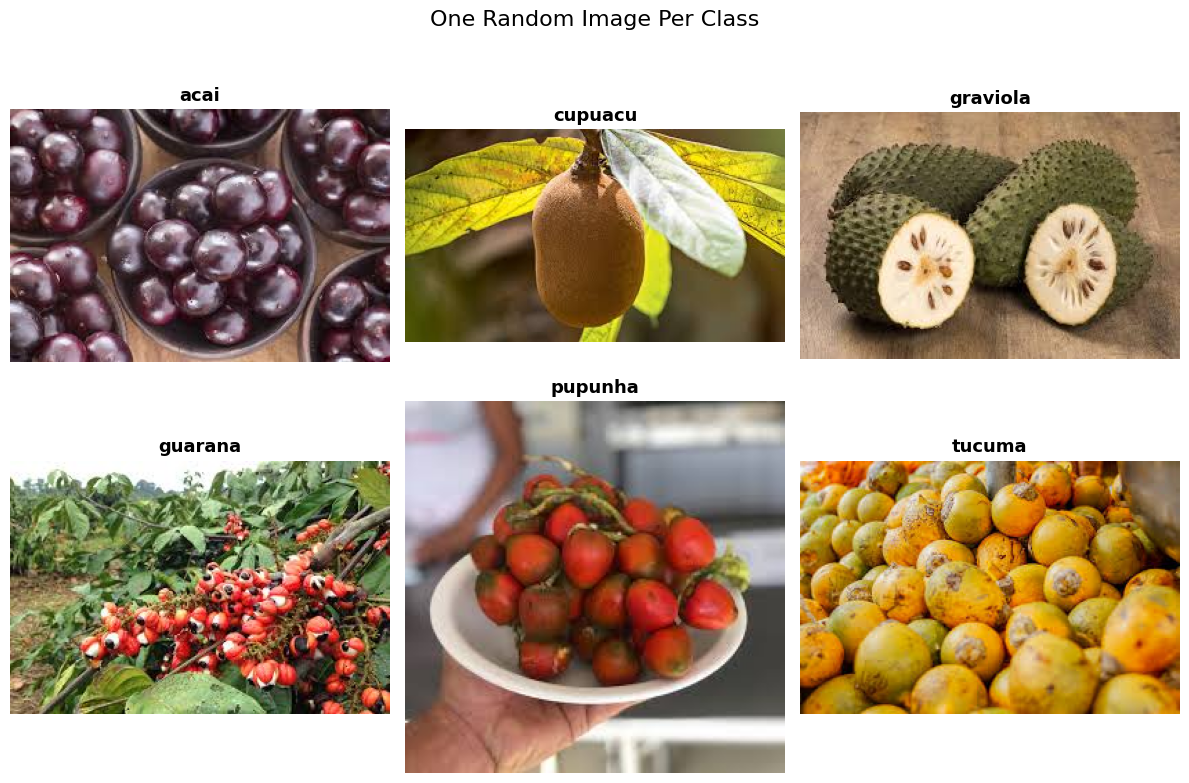


Observation: The dataset contains images of different Amazon fruits.
Each class has visually distinct characteristics in terms of color,
texture, and shape, which a CNN should be able to learn effectively.


In [10]:
# ============================================================
# TASK 1.1 – Visualise one random image per class in a grid
# ============================================================

# Get list of class directories
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print('Classes found:', class_dirs)
num_classes = len(class_dirs)

# Select one random image from each class
sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    chosen = random.choice(images)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2   # ceiling divide for columns
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for idx, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

# Hide any unused axes
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('One Random Image Per Class', fontsize=16)
plt.tight_layout()
plt.show()

print('\nObservation: The dataset contains images of different Amazon fruits.')
print('Each class has visually distinct characteristics in terms of color,')
print('texture, and shape, which a CNN should be able to learn effectively.')

In [11]:
# ============================================================
# TASK 1.2 – Check for Corrupted Images and Remove Them
# ============================================================

corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()   # verify checks for corruption without fully loading
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted_images:
    print('No Corrupted Images Found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted_images)}')

No Corrupted Images Found.


---
# TASK 2: Loading and Preprocessing Image Data in Keras

In [12]:
# ============================================================
# TASK 2 – Load & Preprocess Data using image_dataset_from_directory
# ============================================================

IMG_HEIGHT     = 128
IMG_WIDTH      = 128
BATCH_SIZE     = 32
VALIDATION_SPLIT = 0.2   # 80% train, 20% validation

# Normalisation layer: scales pixel values from [0,255] → [0,1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ----- Training Dataset -----
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)

# Apply normalisation
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ----- Validation Dataset -----
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)

# Apply normalisation
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ----- Test Dataset -----
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Retrieve class names from the training dataset
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else class_dirs
print('Class names:', class_names)
print('Number of classes:', len(class_names))

# Performance optimisation: prefetch batches to GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
# TASK 3: Build the CNN Model

Architecture as specified in the worksheet:
- Conv(32, 3x3, same) → ReLU → MaxPool(2x2)
- Conv(32, 3x3, same) → ReLU → MaxPool(2x2)
- Flatten → Dense(64) → Dense(128) → Dense(num_classes, softmax)

In [13]:
# ============================================================
# TASK 3 – Build the CNN Architecture
# ============================================================

num_classes = len(class_names)

model = keras.Sequential([

    # ----- Convolutional Block 1 -----
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=1,
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        name='conv_1'
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2,
        name='maxpool_1'
    ),

    # ----- Convolutional Block 2 -----
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=1,
        activation='relu',
        name='conv_2'
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2,
        name='maxpool_2'
    ),

    # ----- Fully Connected Network -----
    layers.Flatten(name='flatten'),

    # Hidden Layer 1
    layers.Dense(64, activation='relu', name='dense_64'),

    # Hidden Layer 2
    layers.Dense(128, activation='relu', name='dense_128'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax', name='output')
], name='Fruits_CNN')

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruits_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
# TASK 4: Compile and Train the Model

In [14]:
# ============================================================
# TASK 4 – Compile the Model
# ============================================================

model.compile(
    optimizer='adam',                          # Adam optimiser
    loss='sparse_categorical_crossentropy',    # suitable for integer labels
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


In [15]:
# ============================================================
# TASK 4 – Train the Model with Callbacks
# ============================================================

# Callback 1: Save the best model (lowest validation loss)
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Callback 2: Stop training early if val_loss doesn't improve
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=20,          # wait 20 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,          # as specified in worksheet
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

print('\nTraining complete.')

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1545 - loss: 2.3635 
Epoch 1: val_loss improved from None to 1.43819, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1667 - loss: 2.5916 - val_accuracy: 0.3889 - val_loss: 1.4382
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2578 - loss: 1.8261
Epoch 2: val_loss did not improve from 1.43819
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3056 - loss: 1.7365 - val_accuracy: 0.6667 - val_loss: 1.4498
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.3281 - loss: 1.5677
Epoch 3: val_loss did not improve from 1.43819
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.4028 - loss: 1.5167 - val_accuracy: 0.1667 - val_loss: 1.6387
Epoch 4/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.3281 - loss: 1.4282
Epoch 4: val_loss did not improve from 1.43819
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.3194 - loss: 1.3919 - val_accuracy: 0.2222 - val_loss: 1.5798
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5625 - loss: 1.1661 
Epoch 5: val_


Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6111 - loss: 1.1867 - val_accuracy: 0.7778 - val_loss: 1.0418
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6609 - loss: 1.0094
Epoch 6: val_loss improved from 1.04178 to 0.94271, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.6389 - loss: 1.0057 - val_accuracy: 0.8333 - val_loss: 0.9427
Epoch 7/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7891 - loss: 0.7918
Epoch 7: val_loss did not improve from 0.94271
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7639 - loss: 0.8097 - val_accuracy: 0.5000 - val_loss: 1.0890
Epoch 8/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9062 - loss: 0.5885 
Epoch 8: val_loss improved from 0.94271 to 0.77129, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8750 - loss: 0.6013 - val_accuracy: 0.8889 - val_loss: 0.7713
Epoch 9/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9375 - loss: 0.3831 
Epoch 9: val_loss improved from 0.77129 to 0.69554, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.8889 - loss: 0.4210 - val_accuracy: 0.8333 - val_loss: 0.6955
Epoch 10/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8984 - loss: 0.3872
Epoch 10: val_loss improved from 0.69554 to 0.50856, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9028 - loss: 0.3766 - val_accuracy: 0.7222 - val_loss: 0.5086
Epoch 11/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9453 - loss: 0.2537
Epoch 11: val_loss did not improve from 0.50856
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9583 - loss: 0.2003 - val_accuracy: 0.7778 - val_loss: 0.7794
Epoch 12/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9531 - loss: 0.2211 
Epoch 12: val_loss did not improve from 0.50856
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9722 - loss: 0.1924 - val_accuracy: 0.8333 - val_loss: 0.7431
Epoch 13/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9844 - loss: 0.1411 
Epoch 13: val_loss improved from 0.50856 to 0.35860, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9722 - loss: 0.1522 - val_accuracy: 0.8889 - val_loss: 0.3586
Epoch 14/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9766 - loss: 0.1005
Epoch 14: val_loss did not improve from 0.35860
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9583 - loss: 0.1415 - val_accuracy: 0.7778 - val_loss: 0.6770
Epoch 15/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9531 - loss: 0.1122
Epoch 15: val_loss did not improve from 0.35860
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9722 - loss: 0.0879 - val_accuracy: 0.7778 - val_loss: 0.4900
Epoch 16/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9531 - loss: 0.1415
Epoch 16: val_loss did not improve from 0.35860
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9722 - loss: 0.1042 - val_accuracy: 0.8333 - val_loss: 0.3986
Epoch 17/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.0224
Ep

---
## Training & Validation Curves

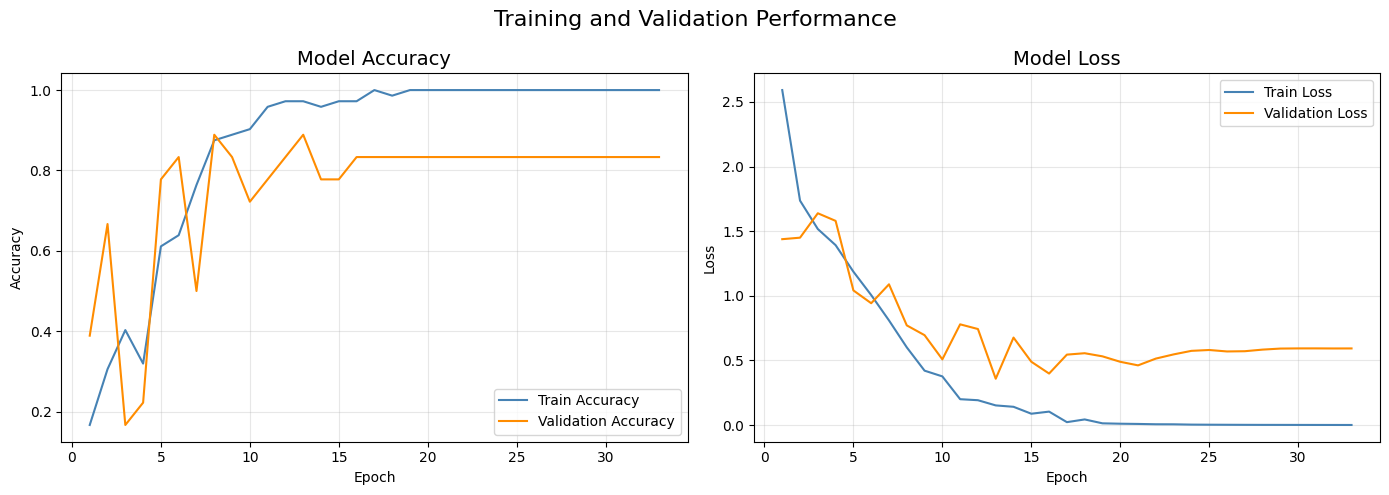

Training curves saved as training_curves.png


In [16]:
# ============================================================
# Plot Training vs Validation — Accuracy and Loss
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
ax1.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs_range, history.history['loss'],     label='Train Loss',      color='steelblue')
ax2.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='darkorange')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training and Validation Performance', fontsize=16)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved as training_curves.png')

---
# TASK 5: Evaluate the Model

In [17]:
# ============================================================
# TASK 5 – Evaluate on Test Set
# ============================================================

test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f'\n===== Test Results =====')
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.7000 - loss: 1.2490

===== Test Results =====
Test Loss    : 1.2490
Test Accuracy: 0.7000  (70.00%)


---
# TASK 6: Save and Load the Model

In [18]:
# ============================================================
# TASK 6 – Save the Model
# ============================================================

model.save('fruits_cnn_model.h5')
print('Model saved as fruits_cnn_model.h5')

Model saved as fruits_cnn_model.h5


In [19]:
# ============================================================
# TASK 6 – Load the Saved Model and Re-evaluate
# ============================================================

loaded_model = keras.models.load_model('fruits_cnn_model.h5')
print('Model loaded successfully.')

# Re-evaluate on test set
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f'\n===== Loaded Model – Test Results =====')
print(f'Test Loss    : {loaded_loss:.4f}')
print(f'Test Accuracy: {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)')

Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 1.2490

===== Loaded Model – Test Results =====
Test Loss    : 1.2490
Test Accuracy: 0.7000  (70.00%)


---
# TASK 7: Predictions and Classification Report

In [20]:
# ============================================================
# TASK 7.1 – Make Predictions on the Test Set
# ============================================================

# Collect all true labels and predictions from test_ds
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(y_pred_probs, axis=1)   # convert probabilities → class index

print('True labels (first 10)     :', y_true[:10])
print('Predicted labels (first 10):', y_pred[:10])

# Map indices back to class names for display
print('\nMapped predictions (first 10):')
for i in range(min(10, len(y_true))):
    print(f'  True: {class_names[y_true[i]]:12s}  |  Predicted: {class_names[y_pred[i]]}')

True labels (first 10)     : [0 0 0 0 0 1 1 1 1 1]
Predicted labels (first 10): [0 0 0 0 0 1 2 2 2 1]

Mapped predictions (first 10):
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: acai          |  Predicted: acai
  True: cupuacu       |  Predicted: cupuacu
  True: cupuacu       |  Predicted: graviola
  True: cupuacu       |  Predicted: graviola
  True: cupuacu       |  Predicted: graviola
  True: cupuacu       |  Predicted: cupuacu


In [21]:
# ============================================================
# TASK 7.2 – Classification Report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print('===== Classification Report =====')
print(report)

===== Classification Report =====
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.56      1.00      0.71         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.78      0.70      0.67        30
weighted avg       0.78      0.70      0.67        30



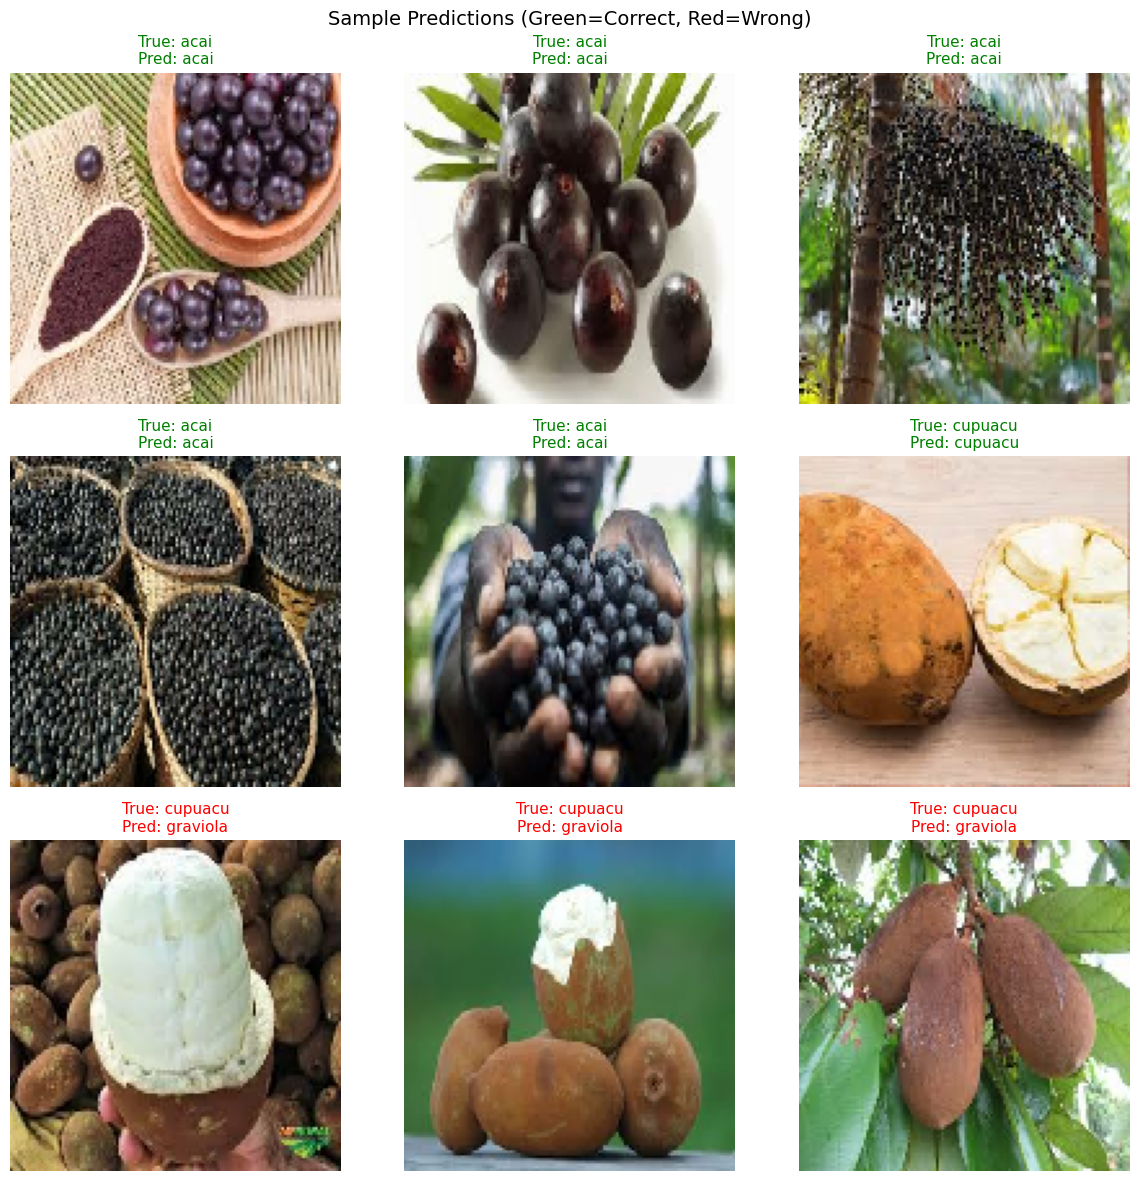

In [22]:
# ============================================================
# BONUS: Visualise Sample Predictions
# ============================================================

# Take the first batch from test_ds for visualisation
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_batch, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(9, len(sample_images_batch))
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(n_show):
    img = sample_images_batch[i].numpy()
    true_label = class_names[sample_labels_batch[i]]
    pred_label = class_names[sample_pred_labels[i]]
    correct = true_label == pred_label

    axes[i].imshow(img)
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label}',
        color=color, fontsize=11
    )
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()